# Notebook 2 - Model Architecture & Training

Implements a CNN encoder + LSTM decoder image-captioning model on Flickr8k.

**Fusion method:** Concatenation - at each decoder step the image embedding
and the word embedding are concatenated and projected back to `embed_dim`
before being fed into the LSTM.

### Setup

In [1]:
import os, random, math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
import torchvision.models as models
from torchvision.models import ResNet50_Weights
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.utils.tensorboard import SummaryWriter

# reproducibility
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# device
DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Device: {DEVICE}")

Device: cuda


In [2]:
# hyperparameters
EMBED_DIM = 256
HIDDEN_DIM = 512
NUM_LAYERS = 1
DROPOUT = 0.5
LEARNING_RATE = 3e-4
BATCH_SIZE = 32
NUM_EPOCHS = 64
GRAD_CLIP = 5.0
FREQ_THRESHOLD = 5
NUM_WORKERS = 8

## 1. Data Loading

In [3]:
from data import get_loaders

train_loader, val_loader, test_loader, vocab = get_loaders(
    batch_size=BATCH_SIZE,
    freq_threshold=FREQ_THRESHOLD,
    num_workers=NUM_WORKERS,
)

VOCAB_SIZE = len(vocab)
PAD_IDX = vocab.stoi["<PAD>"]
SOS_IDX = vocab.stoi["<SOS>"]
EOS_IDX = vocab.stoi["<EOS>"]

print(f"Vocabulary size : {VOCAB_SIZE}")
print(f"PAD={PAD_IDX}  SOS={SOS_IDX}  EOS={EOS_IDX}")

/home/popraf/Desktop/studia/D7047E_Advanced_deep_learning_assignments/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading Flickr8k from HuggingFace (jxie/flickr8k)...


Loaded 40000 caption rows over 8000 images
Unique images : 8000
 Train images : 6400 (32000 captions)
 Val images   : 800 (4000 captions)
 Test images  : 800 (4000 captions)
Vocabulary size : 2618
Vocabulary size : 2618
PAD=0  SOS=1  EOS=2


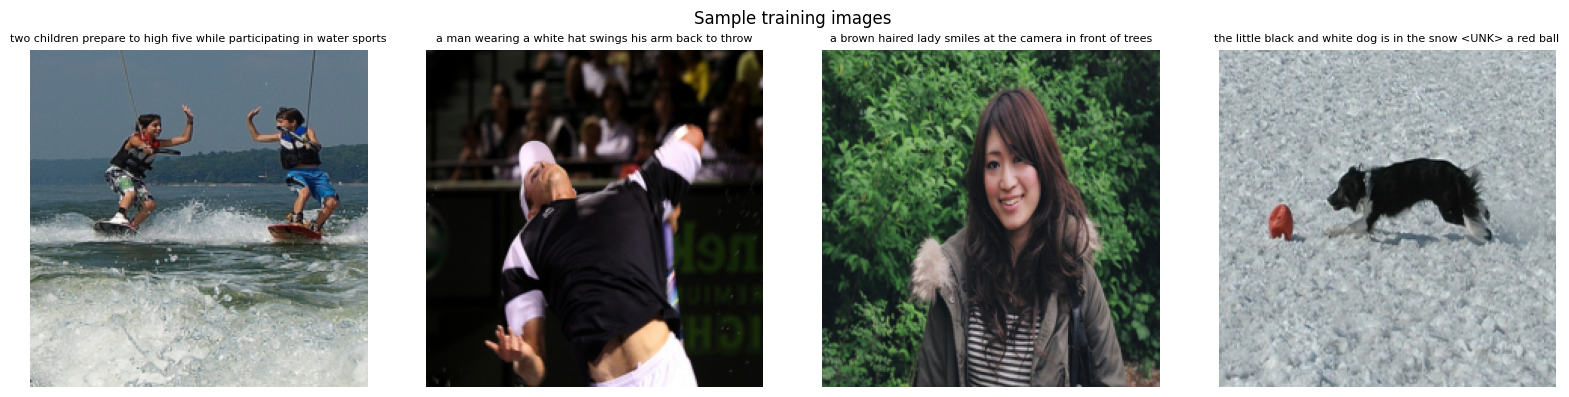

In [4]:
# Visualise 4 training samples
mean = torch.tensor([0.485, 0.456, 0.406]).view(
    3, 1, 1
)  # ImageNet channel means, shape (3,1,1) for broadcasting
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)  # ImageNet channel stds

imgs, caps, _ = next(iter(train_loader))  # imgs: (B, 3, 224, 224), caps: (B, T)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, ax in enumerate(axes):
    # Undo ImageNet normalisation: x_orig = x_norm * std + mean
    # clamp(0,1) guards against floating-point overshoot after denorm
    # permute (C, H, W) → (H, W, C) because matplotlib expects channel-last
    img = (imgs[i] * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
    caption = " ".join(
        vocab.itos[t]
        for t in caps[i].tolist()
        if t not in (PAD_IDX, SOS_IDX, EOS_IDX)  # skip special tokens in display
    )
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(caption, fontsize=8, wrap=True)
plt.suptitle("Sample training images", fontsize=12)
plt.tight_layout()
plt.show()

## 2. CNN Encoder

In [5]:
class EncoderCNN(nn.Module):
    """ResNet-50 backbone with the classification head replaced by a
    linear projection to `embed_dim`. Pretrained weights are frozen."""

    def __init__(self, embed_dim: int):
        super().__init__()
        resnet = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        feature_dim = (
            resnet.fc.in_features
        )  # 2048 - width of ResNet-50's penultimate (avg-pool) layer
        resnet.fc = nn.Identity()  # replace 1000-class softmax head with a pass-through

        for param in resnet.parameters():
            param.requires_grad = (
                False  # freeze backbone; only projection + BN will be trained
            )

        self.backbone = resnet
        self.projection = nn.Linear(
            feature_dim, embed_dim
        )  # learned down-projection: 2048 → embed_dim
        self.bn = nn.BatchNorm1d(
            embed_dim, momentum=0.01
        )  # stabilises projection output distribution
        self.relu = nn.ReLU()

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        # images: (B, 3, 224, 224)  - ImageNet-normalised RGB batch
        with torch.no_grad():  # backbone is frozen; no gradients needed here
            features = self.backbone(
                images
            )  # (B, 2048)  - global-average-pooled spatial features
        features = self.projection(
            features
        )  # (B, embed_dim)  - compress to shared embedding space
        out = self.relu(
            self.bn(features)
        )  # (B, embed_dim)  - batch-norm then ReLU activation
        return out

In [6]:
# Sanity check
_enc = EncoderCNN(EMBED_DIM).to(DEVICE)
_dummy = torch.zeros(2, 3, 224, 224, device=DEVICE)
_out = _enc(_dummy)
assert _out.shape == (2, EMBED_DIM), f"Unexpected shape: {_out.shape}"
print(f"EncoderCNN output: {_out.shape}")
del _enc, _dummy, _out

EncoderCNN output: torch.Size([2, 256])


## 3. LSTM Decoder

**Fusion - Concatenation:** at each time step the image embedding
*(B, embed_dim)* is expanded and concatenated with the word embedding
*(B, T, embed_dim)* → *(B, T, 2·embed_dim)*, then projected back to
*embed_dim* before entering the LSTM. This preserves the full information
from both modalities without any information loss.

In [7]:
class DecoderLSTM(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        embed_dim: int,
        hidden_dim: int,
        num_layers: int,
        dropout: float,
        pad_idx: int,
    ):
        super().__init__()
        self.embed = nn.Embedding(
            vocab_size, embed_dim, padding_idx=pad_idx
        )  # token id → dense vector
        self.dropout = nn.Dropout(dropout)
        # Concatenation fusion: [image_embed || word_embed] has width 2*embed_dim; project back to embed_dim
        # so the LSTM always sees a fixed-size input regardless of embed_dim value
        self.fusion_proj = nn.Linear(embed_dim + embed_dim, embed_dim)
        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            num_layers,
            batch_first=True,
            dropout=dropout
            if num_layers > 1
            else 0.0,  # inter-layer dropout only meaningful when stacking LSTMs
        )
        self.fc_out = nn.Linear(
            hidden_dim, vocab_size
        )  # hidden state → per-token vocabulary logits

    def forward(
        self,
        image_embed: torch.Tensor,  # (B, embed_dim)  - encoder output, one vector per image in batch
        captions: torch.Tensor,  # (B, T)           - teacher-forced token ids: [SOS, w1, w2, ..., wT-1]
        lengths: torch.Tensor,  # (B,)             - true (non-padded) length of each caption sequence
    ) -> torch.Tensor:  # (B, T', vocab_size)  T' = max real length after packing

        T = captions.size(
            1
        )  # max caption length in this batch (time steps fed to decoder)

        word_embeds = self.dropout(
            self.embed(captions)
        )  # (B, T, E)  - each token id → E-dim vector
        img_exp = image_embed.unsqueeze(1).expand(
            -1, T, -1
        )  # (B, T, E)  - repeat image embed at each step

        # Concatenation fusion: join visual context with linguistic context at every time step
        fused = torch.cat(
            [img_exp, word_embeds], dim=-1
        )  # (B, T, 2E) - concatenated along feature axis
        fused = self.dropout(
            F.relu(self.fusion_proj(fused))
        )  # (B, T, E)  - project 2E → E, then activate

        # pack_padded_sequence compacts the ragged batch: PAD positions are removed so the LSTM
        # never processes them, saving compute and preventing PAD from influencing hidden state
        packed = pack_padded_sequence(
            fused, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        lstm_out, _ = self.lstm(packed)  # packed output; _ = (h_n, c_n) not needed
        lstm_out, _ = pad_packed_sequence(
            lstm_out, batch_first=True
        )  # (B, T', H)  T' ≤ T (max real length in batch)

        logits = self.fc_out(lstm_out)  # (B, T', V)  - unnormalised next-token scores
        return logits

In [8]:
# Sanity check
_dec = DecoderLSTM(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT, PAD_IDX).to(
    DEVICE
)
_img = torch.zeros(2, EMBED_DIM, device=DEVICE)
_caps = torch.zeros(2, 10, dtype=torch.long, device=DEVICE)
_lens = torch.tensor([10, 8])
_out = _dec(_img, _caps, _lens)
assert _out.shape == (2, 10, VOCAB_SIZE), f"Unexpected shape: {_out.shape}"
print(f"DecoderLSTM output: {_out.shape}")
del _dec, _img, _caps, _lens, _out

DecoderLSTM output: torch.Size([2, 10, 2618])


## 4. Full Model

In [9]:
class CaptioningModel(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        embed_dim: int,
        hidden_dim: int,
        num_layers: int,
        dropout: float,
        pad_idx: int,
    ):
        super().__init__()
        self.encoder = EncoderCNN(embed_dim)  # image  → (B, E)
        self.decoder = DecoderLSTM(
            vocab_size,
            embed_dim,
            hidden_dim,
            num_layers,
            dropout,
            pad_idx,  # tokens → (B, T, V)
        )

    def forward(
        self,
        images: torch.Tensor,  # (B, 3, 224, 224)  - normalised input images
        captions: torch.Tensor,  # (B, T)             - teacher-forced caption token ids
        lengths: torch.Tensor,  # (B,)               - true sequence lengths (excl. EOS, after strip)
    ) -> torch.Tensor:  # (B, T', vocab_size) - per-step vocabulary logits
        image_embed = self.encoder(images)  # (B, E)     - visual context vector
        logits = self.decoder(
            image_embed, captions, lengths
        )  # (B, T', V) - caption logits
        return logits


model = CaptioningModel(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    pad_idx=PAD_IDX,
).to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Parameters - trainable: {trainable:,}  /  total: {total:,}")

Parameters - trainable: 4,246,586  /  total: 27,754,618


## 5. Loss, Optimizer, Scheduler

`CrossEntropyLoss(ignore_index=PAD_IDX)` is essential because captions in a
batch are padded to equal length with `<PAD>` tokens. Without `ignore_index`,
the loss would penalise the model for not predicting `<PAD>` at those positions,
which is meaningless - they carry no linguistic content. Setting `ignore_index`
zeroes out the gradient contribution from every `<PAD>` position and excludes
them from the averaging denominator, so the reported loss reflects only real
token predictions.

In [10]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=2, factor=0.5
)

print("Criterion, optimizer, scheduler ready.")

Criterion, optimizer, scheduler ready.


In [11]:
writer = SummaryWriter(log_dir="runs/captioning")
print(f"TensorBoard log dir: {os.path.abspath('runs/captioning')}")

TensorBoard log dir: /home/popraf/Desktop/studia/D7047E_Advanced_deep_learning_assignments/lab3/runs/captioning


## 6. Training Loop

In [12]:
def train_one_epoch(model, loader, optimizer, criterion, device, grad_clip):
    model.train()
    total_loss, n_batches = 0.0, 0

    for imgs, captions, lengths in tqdm(loader, desc="  train", leave=False):
        imgs = imgs.to(device, non_blocking=True)  # (B, 3, 224, 224)
        captions = captions.to(device, non_blocking=True)  # (B, T+1)

        # Teacher forcing: at each step the decoder receives the ground-truth previous token
        # inputs:  [SOS, w1, w2, ..., wT-1]  - strip EOS; shape (B, T)
        # targets: [w1,  w2, ..., wT-1, EOS] - strip SOS; shape (B, T)  (one-step-ahead prediction)
        inputs = captions[:, :-1]  # (B, T)  - drop last token (EOS) from decoder input
        targets = captions[:, 1:]  # (B, T)  - drop first token (SOS) from target
        inp_len = (lengths - 1).clamp(
            min=1
        )  # (B,)    - sequence lengths shrink by 1 after stripping

        logits = model(
            imgs, inputs, inp_len
        )  # (B, T', vocab_size)  T' = max real length after pack/unpack

        # T' from pad_packed_sequence may be < T when the longest non-padded sequence is shorter than T
        T = min(logits.size(1), targets.size(1))
        loss = criterion(
            logits[:, :T, :].reshape(
                -1, VOCAB_SIZE
            ),  # (B*T, vocab_size) - CrossEntropyLoss expects 2-D input
            targets[:, :T].reshape(-1),  # (B*T,)  and 1-D class indices
        )

        optimizer.zero_grad(set_to_none=True)  # deallocate rather than zero-fill
        loss.backward()
        nn.utils.clip_grad_norm_(
            model.parameters(), grad_clip
        )  # cap gradient norm to prevent LSTM exploding gradients
        optimizer.step()

        total_loss += loss.item()
        n_batches += 1

    return total_loss / max(n_batches, 1)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, n_batches = 0.0, 0

    for imgs, captions, lengths in tqdm(loader, desc="  val  ", leave=False):
        imgs = imgs.to(device, non_blocking=True)  # (B, 3, 224, 224)
        captions = captions.to(device, non_blocking=True)  # (B, T+1)

        inputs = captions[:, :-1]  # (B, T)  - decoder inputs without EOS
        targets = captions[:, 1:]  # (B, T)  - targets without SOS
        inp_len = (lengths - 1).clamp(min=1)  # (B,)

        logits = model(imgs, inputs, inp_len)  # (B, T', vocab_size)

        T = min(logits.size(1), targets.size(1))
        loss = criterion(
            logits[:, :T, :].reshape(-1, VOCAB_SIZE),  # (B*T, vocab_size)
            targets[:, :T].reshape(-1),  # (B*T,)
        )
        total_loss += loss.item()
        n_batches += 1

    return total_loss / max(n_batches, 1)

In [13]:
train_losses, val_losses = [], []
best_val_loss = math.inf
CHECKPOINT_PATH = "checkpoint_best.pth"

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_epoch(
        model, train_loader, optimizer, criterion, DEVICE, GRAD_CLIP
    )
    val_loss = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    writer.add_scalar("Loss/train", train_loss, epoch)
    writer.add_scalar("Loss/val", val_loss, epoch)
    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} "
        f"| train_loss: {train_loss:.4f} "
        f"| val_loss: {val_loss:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(
            {
                "epoch": epoch,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "val_loss": val_loss,
                "vocab": vocab,
                "hparams": {
                    "embed_dim": EMBED_DIM,
                    "hidden_dim": HIDDEN_DIM,
                    "num_layers": NUM_LAYERS,
                    "dropout": DROPOUT,
                },
            },
            CHECKPOINT_PATH,
        )
        print(f"    saved checkpoint (val_loss={best_val_loss:.4f})")


writer.close()
print(f"\nTraining complete. Best val_loss: {best_val_loss:.4f}")

Epoch 01/64 | train_loss: 4.2158 | val_loss: 3.6216
    saved checkpoint (val_loss=3.6216)


Epoch 02/64 | train_loss: 3.5196 | val_loss: 3.2966
    saved checkpoint (val_loss=3.2966)


Epoch 03/64 | train_loss: 3.2593 | val_loss: 3.1342
    saved checkpoint (val_loss=3.1342)


Epoch 04/64 | train_loss: 3.0992 | val_loss: 3.0359
    saved checkpoint (val_loss=3.0359)


Epoch 05/64 | train_loss: 2.9847 | val_loss: 2.9704
    saved checkpoint (val_loss=2.9704)


...

Epoch 51/64 | train_loss: 2.1301 | val_loss: 2.7563


Epoch 52/64 | train_loss: 2.1287 | val_loss: 2.7600


Epoch 53/64 | train_loss: 2.1305 | val_loss: 2.7586


Epoch 54/64 | train_loss: 2.1304 | val_loss: 2.7609


KeyboardInterrupt: 

## 7. Save Artifacts

In [14]:
torch.save(vocab, "vocab.pth")
print(f"vocab.pth saved  (vocab size: {len(vocab)})")
assert os.path.exists("checkpoint_best.pth")
assert os.path.exists("vocab.pth")

vocab.pth saved  (vocab size: 2618)


## 8. Training Curves

In [ ]:
# %load_ext tensorboard
# %tensorboard --logdir runs/

Reusing TensorBoard on port 6006 (pid 78198), started 0:00:01 ago. (Use '!kill 78198' to kill it.)